# Домашнее задание 1.1: Математический маятник

Линейная модель маятника малых колебаний:

$$\ddot\theta + \omega_0^2 \theta = 0$$

Задача решается методом Эйлера и методом Рунге — Кутты 4-го порядка (RK4), результаты
сравниваются с точным аналитическим решением. Расчёт повторяется для нескольких значений
шага интегрирования $dt$.



In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 110

## 1. Постановка задачи

Уравнение малых колебаний маятника переписывается как система первого порядка.
Состояние: $y = (\theta, \dot\theta)$.

$$\dot y = f(y) = \begin{pmatrix} \dot\theta \\ -\omega_0^2 \theta \end{pmatrix}$$

Параметры: $\omega_0^2 = g / L$, единицы приведены к $L = 1$, $\omega_0 = 2$ рад/с.
Начальные условия: $\theta_0 = 0.3$ рад, $\dot\theta_0 = 0$.

In [2]:
omega0 = 2.0       # собственная частота, рад/с
theta0 = 0.3       # начальный угол, рад
dtheta0 = 0.0      # начальная угловая скорость, рад/с
t_end = 10.0       # интервал моделирования, с


def f(y):
    theta, dtheta = y
    return np.array([dtheta, -omega0**2 * theta])


def exact_solution(t):
    theta = theta0 * np.cos(omega0 * t) + (dtheta0 / omega0) * np.sin(omega0 * t)
    dtheta = -theta0 * omega0 * np.sin(omega0 * t) + dtheta0 * np.cos(omega0 * t)
    return theta, dtheta

## 2. Методы интегрирования

Метод Эйлера (явный, первый порядок):

$$y_{n+1} = y_n + dt \cdot f(y_n)$$

Метод Рунге — Кутты 4-го порядка:

$$k_1 = f(y_n), \quad k_2 = f(y_n + \tfrac{dt}{2}k_1), \quad k_3 = f(y_n + \tfrac{dt}{2}k_2), \quad k_4 = f(y_n + dt\, k_3)$$
$$y_{n+1} = y_n + \frac{dt}{6}(k_1 + 2k_2 + 2k_3 + k_4)$$

In [3]:
def integrate_euler(dt, t_end=t_end):
    n_steps = int(round(t_end / dt))
    t = np.linspace(0, n_steps * dt, n_steps + 1)
    y = np.zeros((n_steps + 1, 2))
    y[0] = [theta0, dtheta0]
    for i in range(n_steps):
        y[i + 1] = y[i] + dt * f(y[i])
    return t, y


def integrate_rk4(dt, t_end=t_end):
    n_steps = int(round(t_end / dt))
    t = np.linspace(0, n_steps * dt, n_steps + 1)
    y = np.zeros((n_steps + 1, 2))
    y[0] = [theta0, dtheta0]
    for i in range(n_steps):
        k1 = f(y[i])
        k2 = f(y[i] + dt / 2 * k1)
        k3 = f(y[i] + dt / 2 * k2)
        k4 = f(y[i] + dt * k3)
        y[i + 1] = y[i] + dt / 6 * (k1 + 2 * k2 + 2 * k3 + k4)
    return t, y

## 3. Сравнение с точным решением, $dt = 0.05$ с

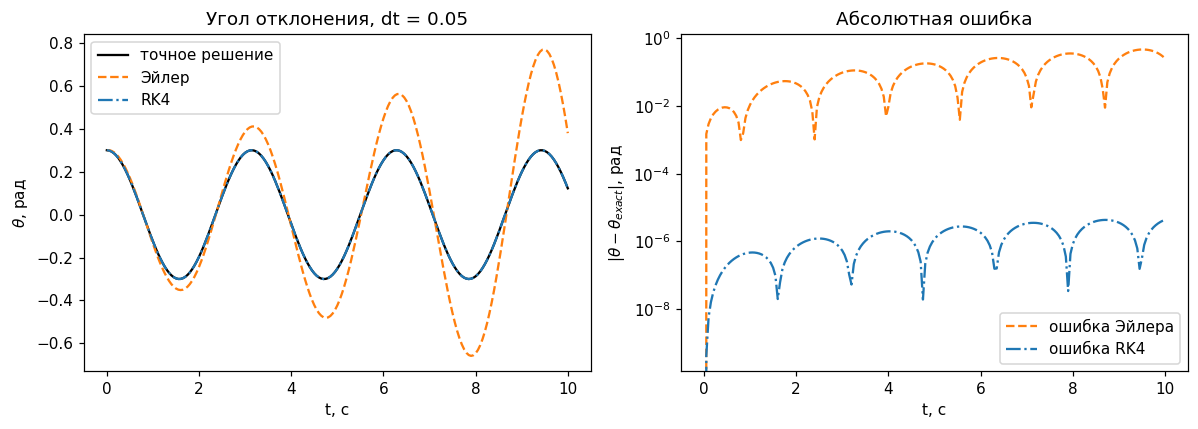

In [4]:
dt_demo = 0.05
t_e, y_e = integrate_euler(dt_demo)
t_r, y_r = integrate_rk4(dt_demo)
theta_exact_e, dtheta_exact_e = exact_solution(t_e)
theta_exact_r, dtheta_exact_r = exact_solution(t_r)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(t_e, theta_exact_e, "k-", label="точное решение", linewidth=1.5)
axes[0].plot(t_e, y_e[:, 0], "C1--", label="Эйлер")
axes[0].plot(t_r, y_r[:, 0], "C0-.", label="RK4")
axes[0].set_xlabel("t, с")
axes[0].set_ylabel(r"$\theta$, рад")
axes[0].set_title(f"Угол отклонения, dt = {dt_demo}")
axes[0].legend()

axes[1].plot(t_e, np.abs(y_e[:, 0] - theta_exact_e), "C1--", label="ошибка Эйлера")
axes[1].plot(t_r, np.abs(y_r[:, 0] - theta_exact_r), "C0-.", label="ошибка RK4")
axes[1].set_xlabel("t, с")
axes[1].set_ylabel(r"$|\theta - \theta_{exact}|$, рад")
axes[1].set_title("Абсолютная ошибка")
axes[1].set_yscale("log")
axes[1].legend()

fig.tight_layout()
plt.show()

## 4. Расчёт для нескольких шагов интегрирования

Расчёт повторяется для набора шагов $dt$. Для каждого шага фиксируется максимальная
абсолютная ошибка по $\theta$ на интервале моделирования.

In [5]:
dt_values = np.array([0.2, 0.1, 0.05, 0.025, 0.0125, 0.00625])

max_err_euler = []
max_err_rk4 = []

for dt in dt_values:
    t, y = integrate_euler(dt)
    theta_exact, _ = exact_solution(t)
    max_err_euler.append(np.max(np.abs(y[:, 0] - theta_exact)))

    t, y = integrate_rk4(dt)
    theta_exact, _ = exact_solution(t)
    max_err_rk4.append(np.max(np.abs(y[:, 0] - theta_exact)))

max_err_euler = np.array(max_err_euler)
max_err_rk4 = np.array(max_err_rk4)

print(f"{'dt':>10} {'ошибка Эйлера':>16} {'ошибка RK4':>14}")
for dt, e_e, e_r in zip(dt_values, max_err_euler, max_err_rk4):
    print(f"{dt:10.5f} {e_e:16.6e} {e_r:14.6e}")

        dt    ошибка Эйлера     ошибка RK4
   0.20000     1.195093e+01   1.123832e-03
   0.10000     1.679462e+00   6.953299e-05
   0.05000     4.724970e-01   4.378590e-06
   0.02500     1.813037e-01   2.797287e-07
   0.01250     7.992021e-02   1.766095e-08
   0.00625     3.758491e-02   1.109185e-09


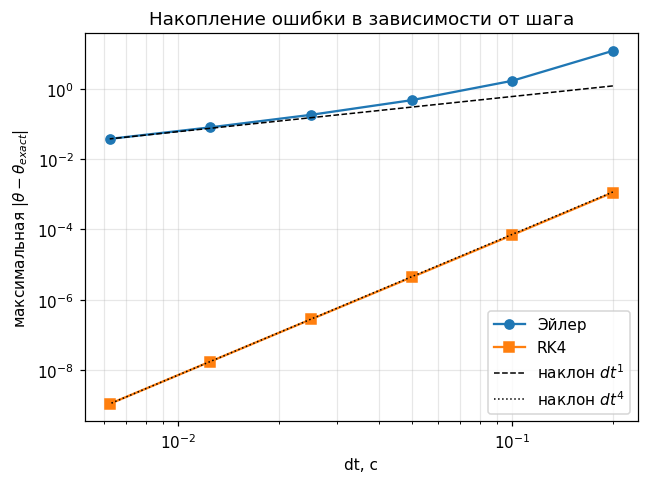

In [6]:
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.loglog(dt_values, max_err_euler, "o-", label="Эйлер")
ax.loglog(dt_values, max_err_rk4, "s-", label="RK4")
ax.loglog(dt_values, max_err_euler[-1] * (dt_values / dt_values[-1]) ** 1, "k--", linewidth=1, label=r"наклон $dt^1$")
ax.loglog(dt_values, max_err_rk4[-1] * (dt_values / dt_values[-1]) ** 4, "k:", linewidth=1, label=r"наклон $dt^4$")
ax.set_xlabel("dt, с")
ax.set_ylabel(r"максимальная $|\theta - \theta_{exact}|$")
ax.set_title("Накопление ошибки в зависимости от шага")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
plt.show()

Порядок сходимости оценивается по наклону логарифмического графика для трёх
наименьших значений $dt$ (асимптотический режим, где локальная погрешность метода
доминирует над эффектом линейной неустойчивости метода Эйлера при большом шаге):
метод Эйлера — первый порядок ($O(dt)$), RK4 — четвёртый порядок ($O(dt^4)$).

In [7]:
n_fit = 3  # число наименьших значений dt, использованных для оценки порядка
order_euler = np.polyfit(np.log(dt_values[-n_fit:]), np.log(max_err_euler[-n_fit:]), 1)[0]
order_rk4 = np.polyfit(np.log(dt_values[-n_fit:]), np.log(max_err_rk4[-n_fit:]), 1)[0]
print(f"Оценка порядка сходимости, метод Эйлера: {order_euler:.2f}")
print(f"Оценка порядка сходимости, метод RK4: {order_rk4:.2f}")

Оценка порядка сходимости, метод Эйлера: 1.14
Оценка порядка сходимости, метод RK4: 3.99


## 5. Фазовая траектория

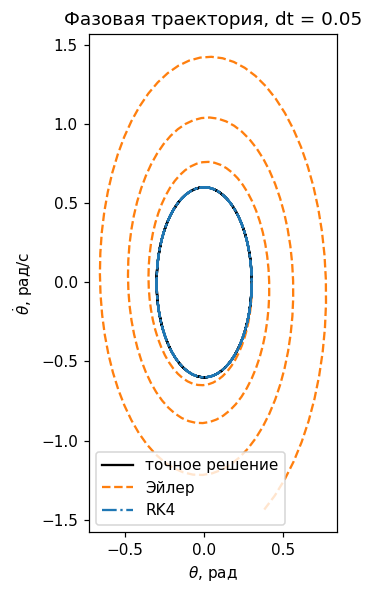

In [8]:
dt_phase = 0.05
t_e, y_e = integrate_euler(dt_phase)
t_r, y_r = integrate_rk4(dt_phase)
theta_ex, dtheta_ex = exact_solution(t_e)

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.plot(theta_ex, dtheta_ex, "k-", linewidth=1.5, label="точное решение")
ax.plot(y_e[:, 0], y_e[:, 1], "C1--", label="Эйлер")
ax.plot(y_r[:, 0], y_r[:, 1], "C0-.", label="RK4")
ax.set_xlabel(r"$\theta$, рад")
ax.set_ylabel(r"$\dot\theta$, рад/с")
ax.set_title(f"Фазовая траектория, dt = {dt_phase}")
ax.set_aspect("equal", adjustable="box")
ax.legend()
fig.tight_layout()
plt.show()

Точное решение линейной модели формирует замкнутый эллипс на фазовой плоскости
(энергия сохраняется). Траектория метода Эйлера раскручивается по спирали наружу —
энергия системы возрастает на каждом шаге. Траектория RK4 при заданном шаге визуально
совпадает с точным эллипсом.

## 6. Энергия системы

Приведённые (на единицу массы, $L = 1$) кинетическая и потенциальная энергии:

$$T = \frac{1}{2}\dot\theta^2, \qquad U = \frac{1}{2}\omega_0^2 \theta^2, \qquad E = T + U$$

Для точного решения линейной модели $E$ постоянна.

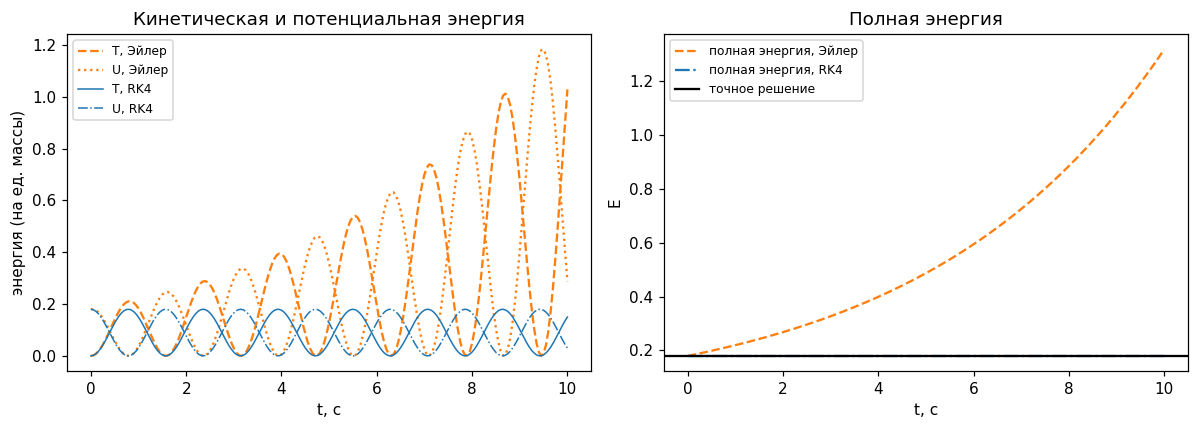

In [9]:
def energies(y):
    theta = y[:, 0]
    dtheta = y[:, 1]
    T = 0.5 * dtheta**2
    U = 0.5 * omega0**2 * theta**2
    return T, U, T + U


dt_energy = 0.05
t_e, y_e = integrate_euler(dt_energy)
t_r, y_r = integrate_rk4(dt_energy)

T_e, U_e, E_e = energies(y_e)
T_r, U_r, E_r = energies(y_r)
E_exact = 0.5 * dtheta0**2 + 0.5 * omega0**2 * theta0**2

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(t_e, T_e, "C1--", label="T, Эйлер")
axes[0].plot(t_e, U_e, "C1:", label="U, Эйлер")
axes[0].plot(t_r, T_r, "C0-", label="T, RK4", linewidth=1)
axes[0].plot(t_r, U_r, "C0-.", label="U, RK4", linewidth=1)
axes[0].set_xlabel("t, с")
axes[0].set_ylabel("энергия (на ед. массы)")
axes[0].set_title("Кинетическая и потенциальная энергия")
axes[0].legend(fontsize=8)

axes[1].plot(t_e, E_e, "C1--", label="полная энергия, Эйлер")
axes[1].plot(t_r, E_r, "C0-.", label="полная энергия, RK4")
axes[1].axhline(E_exact, color="k", linewidth=1.5, label="точное решение")
axes[1].set_xlabel("t, с")
axes[1].set_ylabel("E")
axes[1].set_title("Полная энергия")
axes[1].legend(fontsize=8)

fig.tight_layout()
plt.show()

## 7. Результаты

1. Метод Эйлера воспроизводит траекторию $\theta(t)$ с ошибкой первого порядка по $dt$
   ($O(dt)$); оценка наклона логарифмического графика ошибки подтверждает порядок,
   близкий к 1.
2. Метод RK4 воспроизводит траекторию с ошибкой четвёртого порядка по $dt$ ($O(dt^4)$);
   при равном шаге ошибка RK4 меньше ошибки Эйлера на несколько порядков.
3. На фазовой плоскости точное решение и решение RK4 образуют замкнутую траекторию.
   Траектория метода Эйлера раскручивается наружу — полная энергия системы монотонно
   возрастает на протяжении интегрирования.
4. Полная энергия, вычисленная по решению RK4, отклоняется от точного значения
   незначительно и без выраженного монотонного тренда на рассмотренном интервале
   времени. Полная энергия по решению Эйлера растёт монотонно, что соответствует
   неустойчивости метода Эйлера относительно интеграла энергии для консервативных
   систем.